<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8010/blob/main/Tarea_Reduccio%CC%81n_de_Dimensionalidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Laboratorio Machine Learning: Reducción de Dimensionalidad
## PCA, t-SNE y UMAP

**Universidad de Ingeniería y Tecnología - UTEC**

---

### Integrantes del Grupo:

1. **Nombre Completo:** Jose Carlos Nomberto
2. **Nombre Completo:** ___________________________________
3. **Nombre Completo:** ___________________________________
4. **Nombre Completo:** ___________________________________

**Fecha:** 21-Feb-2026

---

## Objetivo del Laboratorio

En este laboratorio aplicarás técnicas de reducción de dimensionalidad (**PCA**, **t-SNE** y **UMAP**) a tres casos de estudio diferentes. Tu objetivo es:

1. Analizar cada dataset
2. Determinar qué técnica es más apropiada para cada caso
3. Aplicar la técnica seleccionada
4. Visualizar y analizar los resultados
5. Justificar tu elección

**Instrucciones:**
- Completa todos los apartados marcados con `# TODO:`
- Justifica tus decisiones en las celdas de markdown
- Al final, redacta conclusiones sobre lo aprendido

---

## Instalación de Librerías

Ejecuta la siguiente celda para instalar las librerías necesarias:

In [1]:
# Instalar librerías necesarias
!pip install numpy pandas matplotlib seaborn scikit-learn umap-learn

---

## Documentación de las Técnicas

Antes de comenzar, revisa la documentación oficial de cada técnica:

### PCA (Principal Component Analysis)
- **Documentación Scikit-learn:** https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
- **Tutorial:** https://scikit-learn.org/stable/modules/decomposition.html#pca

### t-SNE (t-Distributed Stochastic Neighbor Embedding)
- **Documentación Scikit-learn:** https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html
- **Tutorial:** https://scikit-learn.org/stable/modules/manifold.html#t-sne

### UMAP (Uniform Manifold Approximation and Projection)
- **Documentación UMAP:** https://umap-learn.readthedocs.io/en/latest/
- **Parámetros básicos:** https://umap-learn.readthedocs.io/en/latest/parameters.html
- **Tutorial básico:** https://umap-learn.readthedocs.io/en/latest/basic_usage.html

---

## Importar Librerías

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

---

# CASO 1: Indicadores Socioeconómicos de Países

## Descripción del Dataset

Este dataset contiene indicadores socioeconómicos de diferentes países:
- PIB per cápita
- Esperanza de vida
- Años de escolaridad
- Tasa de mortalidad infantil
- Acceso a internet
- Entre otros indicadores

**Fuente:** Banco Mundial y Naciones Unidas

### 1.1. Cargar Dataset

In [13]:
# Descargar dataset de indicadores socioeconómicos
import urllib.request

url = "https://raw.githubusercontent.com/datasets/gdp/master/data/gdp.csv"

# Para este ejercicio, crearemos un dataset sintético basado en correlaciones lineales
# que simula indicadores socioeconómicos reales
np.random.seed(42)
n_countries = 150

# Variable base: nivel de desarrollo (latente)
desarrollo = np.random.randn(n_countries)

# Variables correlacionadas linealmente con el desarrollo
data_caso1 = pd.DataFrame({
    'PIB_per_capita': 10000 + desarrollo * 8000 + np.random.randn(n_countries) * 1500,
    'Esperanza_vida': 65 + desarrollo * 8 + np.random.randn(n_countries) * 2,
    'Escolaridad': 8 + desarrollo * 3 + np.random.randn(n_countries) * 0.8,
    'Mortalidad_infantil': 30 - desarrollo * 10 + np.random.randn(n_countries) * 3,
    'Acceso_internet': 40 + desarrollo * 25 + np.random.randn(n_countries) * 8,
    'Consumo_energia': 2000 + desarrollo * 1500 + np.random.randn(n_countries) * 400,
    'Urbanizacion': 50 + desarrollo * 20 + np.random.randn(n_countries) * 5,
    'Inflacion': 5 - desarrollo * 2 + np.random.randn(n_countries) * 1.5,
    'Desempleo': 8 - desarrollo * 3 + np.random.randn(n_countries) * 2,
    'Inversion_educacion': 3 + desarrollo * 1.5 + np.random.randn(n_countries) * 0.5
})

# Etiquetas basadas en nivel de desarrollo
labels_caso1 = pd.Series(pd.cut(desarrollo, bins=3, labels=['En Desarrollo', 'Emergente', 'Desarrollado']))

print(f"Dataset cargado: {data_caso1.shape[0]} países, {data_caso1.shape[1]} indicadores")
print("\nPrimeras filas:")
data_caso1.head()

Dataset cargado: 150 países, 10 indicadores

Primeras filas:


,PIB_per_capita,Esperanza_vida,Escolaridad,Mortalidad_infantil,Acceso_internet,Consumo_energia,Urbanizacion,Inflacion,Desempleo,Inversion_educacion
0,14349.452500,67.315723,9.439999,27.303824,45.031988,2892.540553,56.806470,4.194408,4.169631,4.134252
1,9413.557905,62.773524,8.349321,28.616147,25.729916,1635.268023,49.213732,4.632420,4.810832,2.517011
2,14161.471222,71.676096,9.154485,26.131932,48.385227,2983.030736,65.423922,3.888069,7.139860,3.562433
3,22532.619397,78.404979,12.972327,18.836615,86.504881,4795.925530,81.763966,2.768887,4.949221,5.282858
4,8566.381712,63.084970,6.873334,33.581838,26.550975,1725.209565,42.565407,5.541597,7.549439,2.563678


### 1.2. Explorar el Dataset

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PIB_per_capita       150 non-null    float64
 1   Esperanza_vida       150 non-null    float64
 2   Escolaridad          150 non-null    float64
 3   Mortalidad_infantil  150 non-null    float64
 4   Acceso_internet      150 non-null    float64
 5   Consumo_energia      150 non-null    float64
 6   Urbanizacion         150 non-null    float64
 7   Inflacion            150 non-null    float64
 8   Desempleo            150 non-null    float64
 9   Inversion_educacion  150 non-null    float64
dtypes: float64(10)
memory usage: 11.8 KB
None

Estadísticas descriptivas:
       PIB_per_capita  Esperanza_vida  Escolaridad  Mortalidad_infantil  \
count      150.000000      150.000000   150.000000           150.000000   
mean      9448.229686       64.451342     7.6

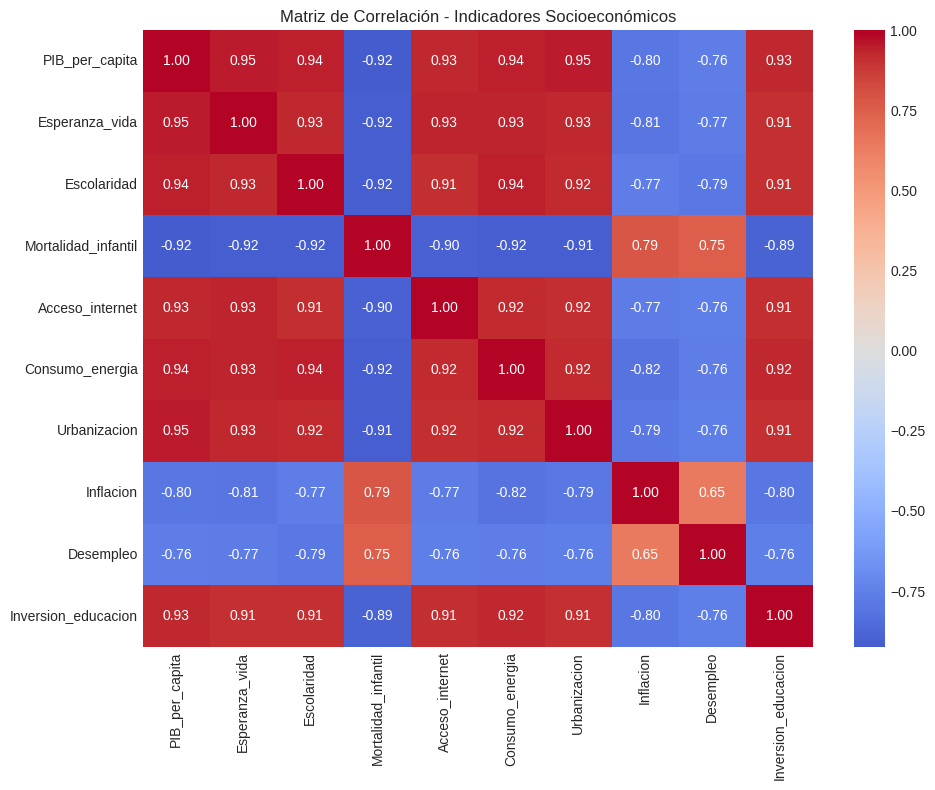

In [14]:
# Información básica
print("Información del dataset:")
print(data_caso1.info())

print("\nEstadísticas descriptivas:")
print(data_caso1.describe())

# Matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(data_caso1.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de Correlación - Indicadores Socioeconómicos')
plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

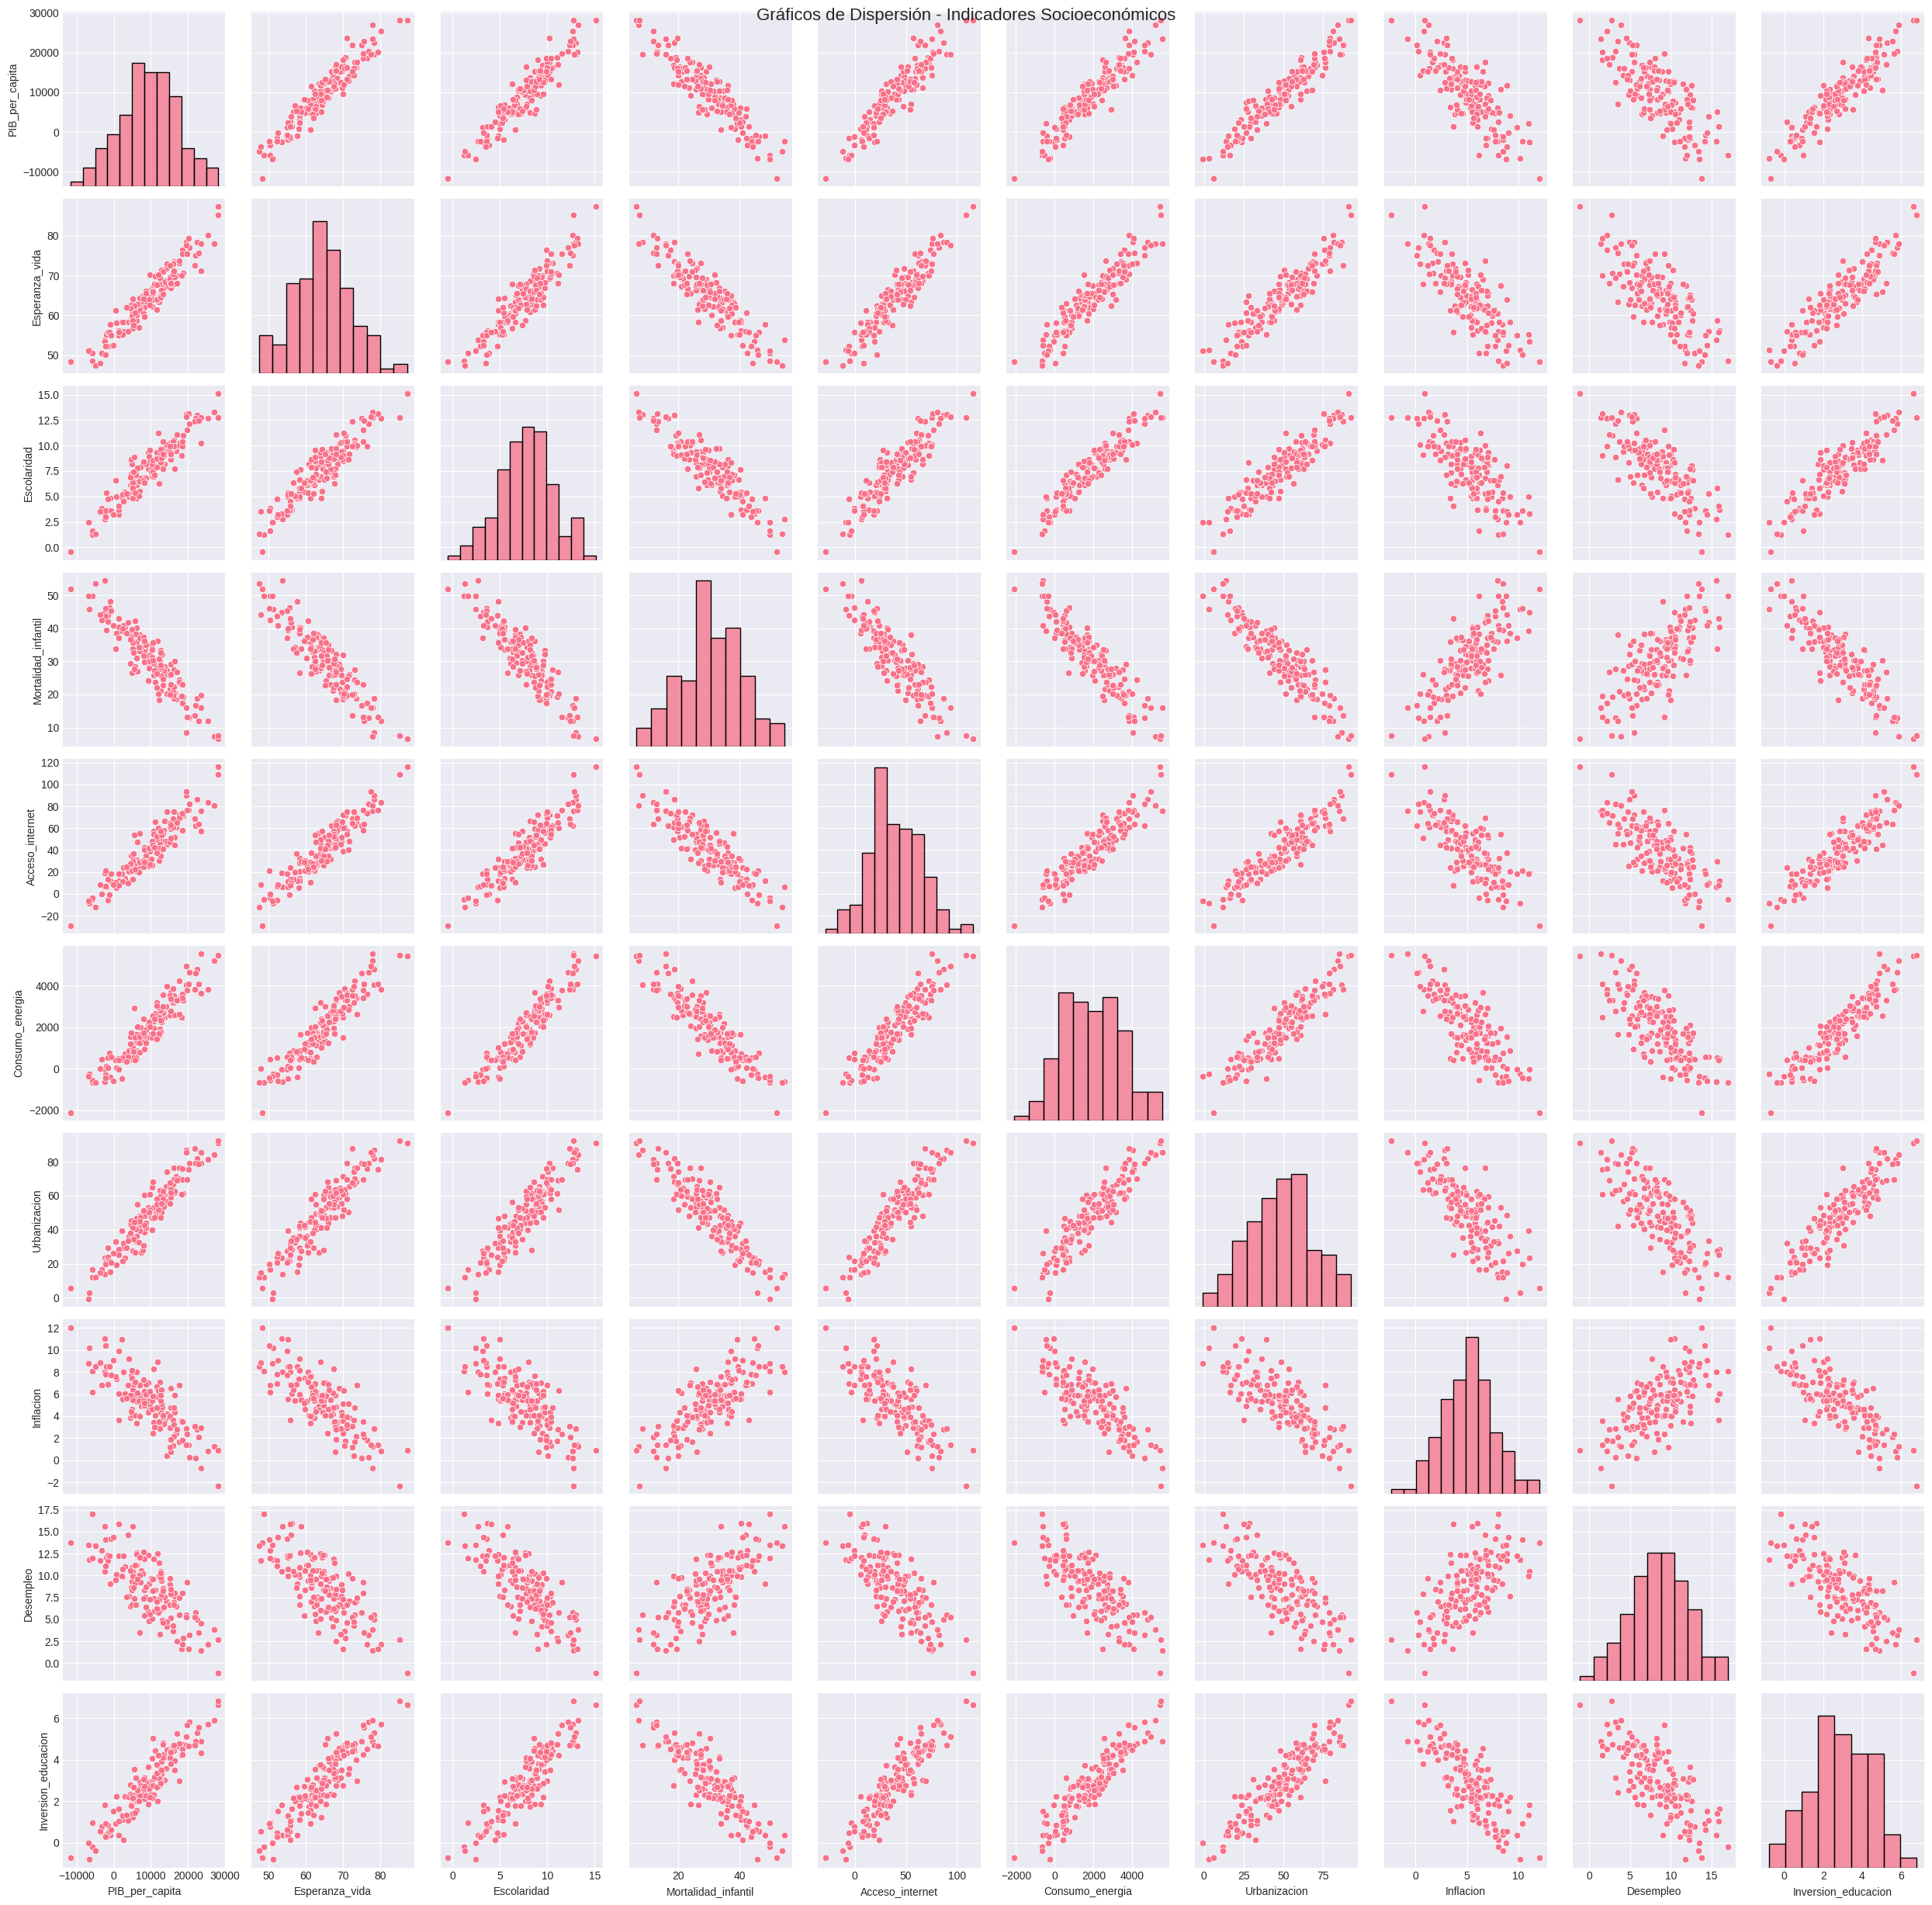

In [15]:
plt.figure(figsize=(12, 8))
sns.pairplot(data_caso1)
plt.suptitle('Gráficos de Dispersión - Indicadores Socioeconómicos', fontsize=16)
plt.tight_layout()
plt.show()

### 1.3. Análisis del Caso

**Preguntas para reflexionar:**

1. ¿Qué observas en la matriz de correlación?
2. ¿Las variables están linealmente correlacionadas?
3. ¿Qué tipo de estructura esperas encontrar en los datos?
4. ¿Necesitas preservar las distancias globales entre grupos de países?
5. ¿Necesitas aplicar el modelo a nuevos países en el futuro?
   Sí

**Escribe tus observaciones aquí:**

1. Se observa que hay fuerte correlación entre las variables, con minima absoluta de 0.65
2. Sí, las variables están linealmente correlacionadas, de acuerdo al diagrama pairplot
3. Estructura lineal entre variables
4.
5. Si

### 1.4. Aplicar Técnica de Reducción de Dimensionalidad

**Instrucciones:**
- Elige la técnica más apropiada para este caso
- Justifica tu elección
- Implementa la técnica seleccionada

#### Justificación de la Técnica Elegida

**Técnica seleccionada:** PCA

**Justificación:**

Se aplica PCA porque como se observa en la matriz de correlacion y diagramas de pairplot, las variables están linealmente correlacionadas, algunas positiva y otras negativamente.

In [25]:
# TODO: Preprocesamiento - Estandarizar datos
scaler_caso1 = StandardScaler()
X_scaled_caso1 = scaler_caso1.fit_transform(data_caso1)

# TODO: Aplicar la técnica seleccionada
# Ejemplo para PCA:
modelo_caso1 = PCA(n_components=2, random_state=42)
X_reducido_caso1 = modelo_caso1.fit_transform(X_scaled_caso1)

# Ejemplo para t-SNE:
# modelo_caso1 = TSNE(n_components=2, random_state=42, perplexity=30)
# X_reducido_caso1 = modelo_caso1.fit_transform(X_scaled_caso1)

# Ejemplo para UMAP:
# modelo_caso1 = umap.UMAP(n_components=2, random_state=42)
# X_reducido_caso1 = modelo_caso1.fit_transform(X_scaled_caso1)

porcentaje_varianza = modelo_caso1.explained_variance_ratio_.sum()
print(f"El porcentaje_varianza explicada con 2 PCA es: {porcentaje_varianza}")


El porcentaje_varianza explicada con 2 PCA es: 0.9179447994123692


### 1.5. Visualizar Resultados

In [18]:
print(labels_caso1.code)

0          Emergente
1          Emergente
2          Emergente
3       Desarrollado
4          Emergente
           ...      
145     Desarrollado
146    En Desarrollo
147    En Desarrollo
148        Emergente
149        Emergente
Length: 150, dtype: category
Categories (3, object): ['En Desarrollo' < 'Emergente' < 'Desarrollado']


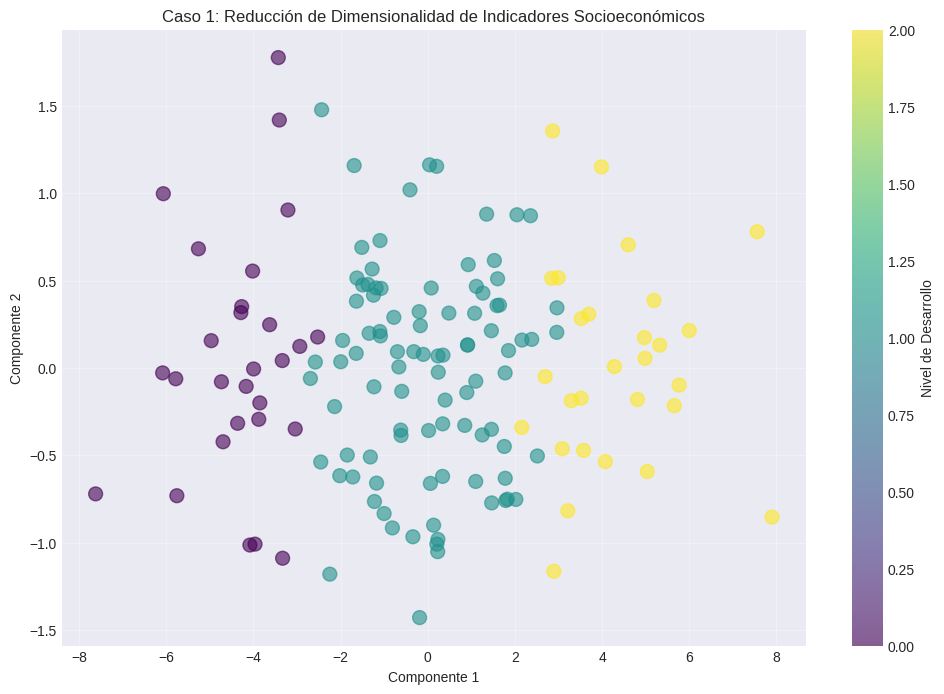

In [20]:
# TODO: Visualizar los resultados

# Plantilla de código:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_reducido_caso1[:, 0], X_reducido_caso1[:, 1],
                      c=labels_caso1.cat.codes, cmap='viridis', alpha=0.6, s=100)
plt.colorbar(scatter, label='Nivel de Desarrollo')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.title('Caso 1: Reducción de Dimensionalidad de Indicadores Socioeconómicos')
plt.grid(True, alpha=0.3)
plt.show()

### 1.6. Análisis de Resultados - Caso 1

**Preguntas:**

1. ¿Se pueden distinguir grupos de países claramente?
2. ¿Tiene sentido la separación que observas?
3. ¿Qué porcentaje de varianza se explicó? (si aplica)
4. ¿Los resultados coinciden con tu hipótesis inicial?

**Respuestas:**

1. Sí, se distinguen 3 grupos de paises
2. Sí tiene sentido la separacion en base al nivel de desarrollo.
3. EL porcentaje varianza explicado es 91.79 con dos PCA
4. Sí, coinciden

---

# CASO 2: Clasificación de Imágenes (Fashion-MNIST)

## Descripción del Dataset

Fashion-MNIST es un dataset de imágenes de ropa y accesorios:
- 70,000 imágenes en escala de grises de 28×28 pixels
- 10 categorías: camiseta, pantalón, jersey, vestido, abrigo, sandalia, camisa, zapatilla, bolso, botín
- Cada imagen tiene 784 dimensiones (28×28)

**Fuente:** Zalando Research

### 2.1. Cargar Dataset

In [26]:
# Descargar Fashion-MNIST desde sklearn
from sklearn.datasets import fetch_openml

print("Descargando Fashion-MNIST (puede tomar unos minutos)...")
fashion_mnist = fetch_openml('Fashion-MNIST', version=1, parser='auto')

# Tomar un subset para velocidad (5000 imágenes)
np.random.seed(42)
indices_caso2 = np.random.choice(len(fashion_mnist.data), size=5000, replace=False)

data_caso2 = fashion_mnist.data.iloc[indices_caso2].values
labels_caso2 = fashion_mnist.target.iloc[indices_caso2].astype(int)

# Nombres de las clases
class_names = ['Camiseta', 'Pantalón', 'Jersey', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

print(f"\nDataset cargado: {data_caso2.shape[0]} imágenes, {data_caso2.shape[1]} dimensiones")
print(f"Clases: {np.unique(labels_caso2)}")

Descargando Fashion-MNIST (puede tomar unos minutos)...

Dataset cargado: 5000 imágenes, 784 dimensiones
Clases: [0 1 2 3 4 5 6 7 8 9]


### 2.2. Explorar el Dataset

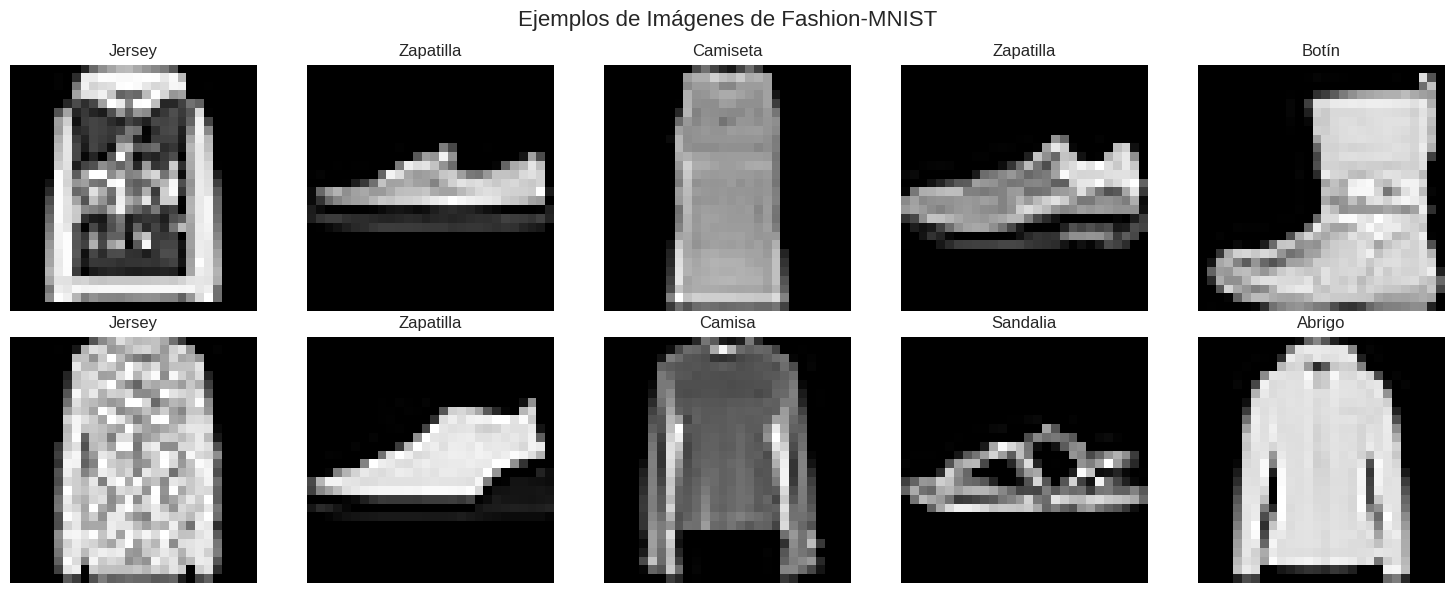

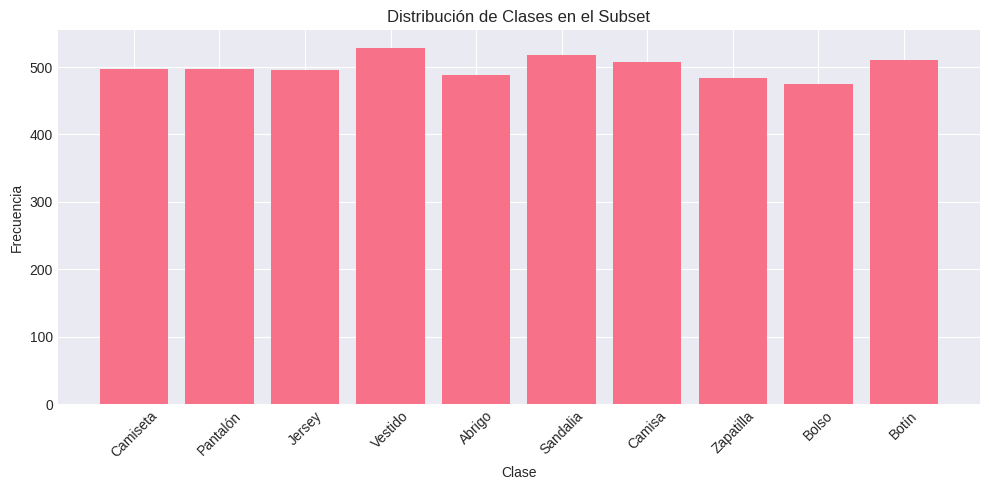

In [27]:
# Visualizar algunas imágenes de ejemplo
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(data_caso2[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'{class_names[labels_caso2.iloc[i]]}')
    ax.axis('off')
plt.suptitle('Ejemplos de Imágenes de Fashion-MNIST', fontsize=16)
plt.tight_layout()
plt.show()

# Distribución de clases
plt.figure(figsize=(10, 5))
unique, counts = np.unique(labels_caso2, return_counts=True)
plt.bar([class_names[i] for i in unique], counts)
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.title('Distribución de Clases en el Subset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.3. Análisis del Caso

**Preguntas para reflexionar:**

1. ¿Cuántas dimensiones tiene cada imagen originalmente?
2. ¿Las relaciones entre imágenes son lineales o no lineales?
3. ¿Qué es más importante: ver clusters bien separados o preservar distancias globales?
4. ¿El dataset es grande o pequeño?
5. ¿Necesitas aplicar el modelo a nuevas imágenes?

**Escribe tus observaciones aquí:**

1. Cada imagen tiene 784 dimensiones
2. Las relaciones entre imagenes son no lineales
3. Para el caso de imagenes es más importantes tener cluster bien separados
4. El dataset es menor a 10K, por lo que es pequeño
5. No, para visualización

### 2.4. Aplicar Técnica de Reducción de Dimensionalidad

**Instrucciones:**
- Elige la técnica más apropiada para este caso
- Justifica tu elección
- Implementa la técnica seleccionada

#### Justificación de la Técnica Elegida

**Técnica seleccionada:* t-SNE

**Justificación:**

* Se elige la técnica de t-SNE ya que el dataset es pequeño, los datos son no lineales, y se requiere visualizar*

In [28]:
# TODO: Preprocesamiento - Estandarizar datos
scaler_caso2 = StandardScaler()
X_scaled_caso2 = scaler_caso2.fit_transform(data_caso2)

# TODO: Aplicar la técnica seleccionada
modelo_caso2 = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_reducido_caso2 = modelo_caso2.fit_transform(X_scaled_caso2)

# Considera usar n_iter=1000 y verificar la convergencia


### 2.5. Visualizar Resultados

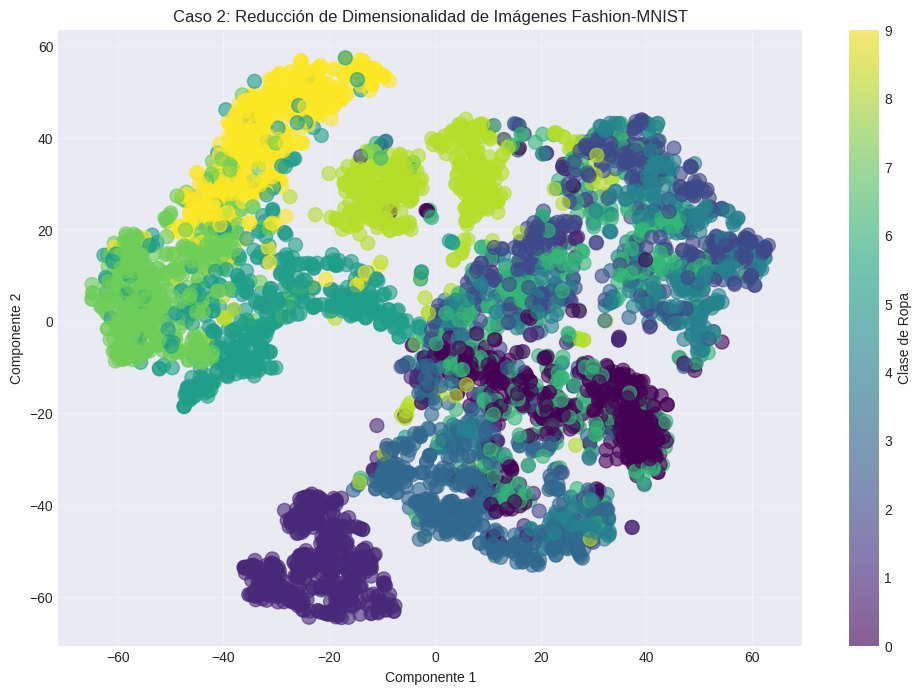

In [32]:
# TODO: Visualizar los resultados
# Tip: Usa diferentes colores para cada clase de ropa

# Plantilla de código:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_reducido_caso2[:, 0], X_reducido_caso2[:, 1],
                      c=labels_caso2, cmap='viridis', alpha=0.6, s=100)
plt.colorbar(scatter, label='Clase de Ropa')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.title('Caso 2: Reducción de Dimensionalidad de Imágenes Fashion-MNIST')
plt.grid(True, alpha=0.3)
plt.show()


### 2.6. Análisis de Resultados - Caso 2

**Preguntas:**

1. ¿Se pueden distinguir las 10 clases de ropa claramente?
2. ¿Qué clases están más cerca entre sí? ¿Tiene sentido?
3. ¿Hay clases que se mezclan? ¿Por qué?
4. ¿La visualización ayuda a entender la estructura de los datos?

**Respuestas:**

1. Sí, se distinguen las 10 clases de ropa en el grafico
2. Las clases 5, 6 y 7 se observan más cercanas entre sí
3. Sí, se observan clases que se mezclan
4. No es suficiente para entender la estructura

---

# CASO 3: Análisis de Expresión Genética (Single-Cell)

## Descripción del Dataset

Este dataset simula datos de expresión genética de células individuales (single-cell RNA-seq):
- Múltiples células de diferentes tipos celulares
- Cada célula tiene expresión de cientos de genes
- Estructura jerárquica: Tipos celulares → Subtipos celulares
- Dataset grande con múltiples escalas de variación

**Nota:** Usaremos datos sintéticos que simulan características reales de datos biológicos

### 3.1. Cargar Dataset

In [33]:
# Crear dataset sintético que simula single-cell RNA-seq
np.random.seed(42)

n_cells = 3000  # Número de células
n_genes = 200   # Número de genes

# Crear 3 tipos celulares principales, cada uno con 3 subtipos
cells_per_subtype = n_cells // 9

data_list = []
type_labels = []
subtype_labels = []

for tipo in range(3):
    for subtipo in range(3):
        # Centros jerárquicos: tipo principal + variación de subtipo
        center_tipo = np.random.randn(n_genes) * 3
        center_subtipo = center_tipo + np.random.randn(n_genes) * 0.5

        # Generar células con estructura no lineal
        cells = center_subtipo + np.random.randn(cells_per_subtype, n_genes) * 0.3

        # Añadir relaciones no lineales
        for i in range(n_genes // 4):
            cells[:, i] = np.abs(cells[:, i])  # Activación

        data_list.append(cells)
        type_labels.extend([f'Tipo_{tipo+1}'] * cells_per_subtype)
        subtype_labels.extend([f'T{tipo+1}_S{subtipo+1}'] * cells_per_subtype)

data_caso3 = np.vstack(data_list)
type_labels_caso3 = np.array(type_labels)
subtype_labels_caso3 = np.array(subtype_labels)

# Convertir a DataFrame
gene_names = [f'Gene_{i+1}' for i in range(n_genes)]
data_caso3_df = pd.DataFrame(data_caso3, columns=gene_names)

print(f"Dataset cargado: {data_caso3.shape[0]} células, {data_caso3.shape[1]} genes")
print(f"\nTipos celulares: {np.unique(type_labels_caso3)}")
print(f"Subtipos celulares: {np.unique(subtype_labels_caso3)}")
print("\nPrimeras células:")
data_caso3_df.head()

Dataset cargado: 2997 células, 200 genes

Tipos celulares: ['Tipo_1' 'Tipo_2' 'Tipo_3']
Subtipos celulares: ['T1_S1' 'T1_S2' 'T1_S3' 'T2_S1' 'T2_S2' 'T2_S3' 'T3_S1' 'T3_S2' 'T3_S3']

Primeras células:


,Gene_1,Gene_2,Gene_3,Gene_4,Gene_5,Gene_6,Gene_7,Gene_8,Gene_9,Gene_10,...,Gene_191,Gene_192,Gene_193,Gene_194,Gene_195,Gene_196,Gene_197,Gene_198,Gene_199,Gene_200
0,1.190708,0.314213,2.486164,5.110085,1.526314,0.984468,4.674870,2.516483,1.114811,3.708378,...,-1.767282,2.671859,0.125859,-2.721388,1.420525,0.768359,-3.589102,0.844482,-0.015932,-2.696813
1,1.896133,0.411050,2.745473,5.502682,1.267264,0.608285,4.763019,2.185801,1.684515,4.002859,...,-1.659867,2.877462,0.063638,-3.204512,0.784946,1.237310,-3.520006,1.342562,0.125852,-2.801076
2,1.950521,0.289214,2.513427,4.957308,1.521644,1.264075,5.061796,2.415573,0.774172,3.285664,...,-1.726237,2.202636,-0.091989,-3.026082,0.808777,0.837034,-2.968834,1.330364,-0.053997,-2.638228
3,2.088843,0.142989,2.502480,4.901910,1.181828,1.053278,5.263714,2.749749,0.836034,3.393475,...,-1.757140,2.414948,-0.198246,-2.725552,0.631365,1.053507,-3.514031,1.303858,0.184530,-2.400761
4,1.706603,0.263222,2.521280,5.258980,1.376637,1.159146,4.784559,2.360327,1.571681,4.078919,...,-1.650761,2.611841,0.586181,-2.780526,0.999666,0.976768,-3.912277,0.846627,0.477480,-3.007071


### 3.2. Explorar el Dataset

Estadísticas del dataset:
            Gene_1       Gene_2       Gene_3       Gene_4       Gene_5  \
count  2997.000000  2997.000000  2997.000000  2997.000000  2997.000000   
mean      2.238640     3.051946     3.376106     2.508512     2.260062   
std       2.262195     3.486476     1.433811     1.878765     1.322099   
min       0.001936     0.000914     0.003328     0.004600     0.003304   
25%       0.695299     0.544552     2.420437     1.024270     1.258291   
50%       1.584048     1.216942     3.422537     1.828809     2.204412   
75%       2.410427     4.914179     4.167065     4.583292     3.106543   
max       8.674588    11.625968     6.805485     6.299671     5.875227   

            Gene_6       Gene_7       Gene_8       Gene_9      Gene_10  ...  \
count  2997.000000  2997.000000  2997.000000  2997.000000  2997.000000  ...   
mean      2.336542     2.415550     2.868446     2.447071     2.824390  ...   
std       2.047549     1.516162     1.047022     1.741664     1.661087

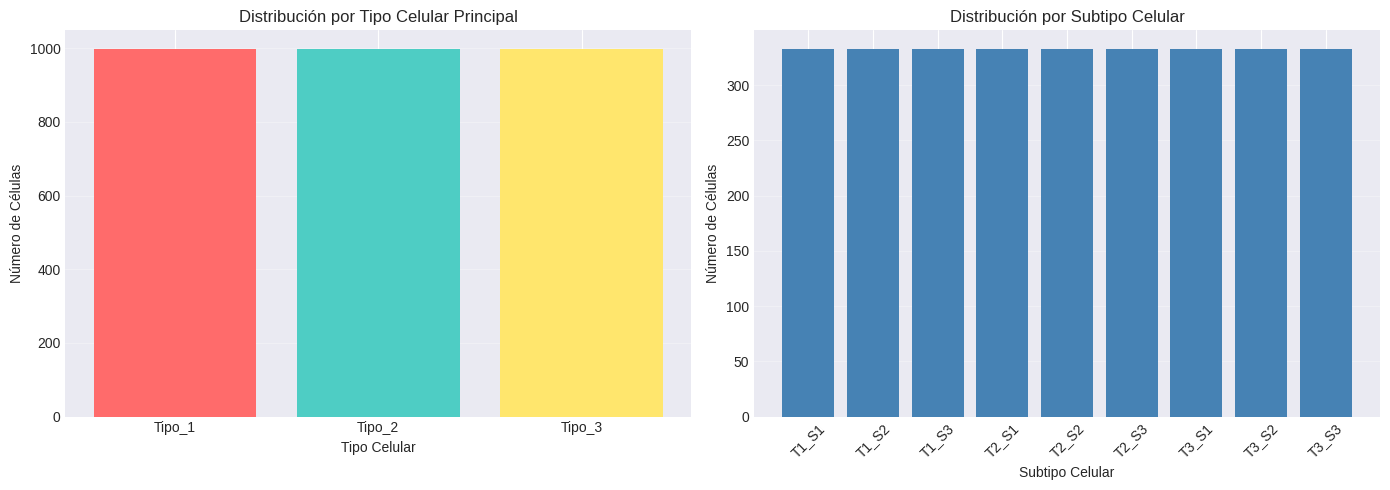

In [34]:
# Estadísticas básicas
print("Estadísticas del dataset:")
print(data_caso3_df.describe())

# Distribución de tipos celulares
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tipos principales
unique_types, counts_types = np.unique(type_labels_caso3, return_counts=True)
axes[0].bar(unique_types, counts_types, color=['#FF6B6B', '#4ECDC4', '#FFE66D'])
axes[0].set_xlabel('Tipo Celular')
axes[0].set_ylabel('Número de Células')
axes[0].set_title('Distribución por Tipo Celular Principal')
axes[0].grid(True, alpha=0.3, axis='y')

# Subtipos
unique_subtypes, counts_subtypes = np.unique(subtype_labels_caso3, return_counts=True)
axes[1].bar(range(len(unique_subtypes)), counts_subtypes, color='steelblue')
axes[1].set_xlabel('Subtipo Celular')
axes[1].set_ylabel('Número de Células')
axes[1].set_title('Distribución por Subtipo Celular')
axes[1].set_xticks(range(len(unique_subtypes)))
axes[1].set_xticklabels(unique_subtypes, rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 3.3. Análisis del Caso

**Preguntas para reflexionar:**

1. ¿Cuántas células y genes tiene el dataset?
2. ¿Existe estructura jerárquica en los datos (tipos → subtipos)?
3. ¿Es importante preservar tanto la separación entre tipos como entre subtipos?
4. ¿El tamaño del dataset es grande?
5. ¿Necesitas velocidad de procesamiento?
6. ¿Las relaciones son lineales o no lineales?

**Escribe tus observaciones aquí:**

1. 2997 celulas y 200 genes
2. Sí, existe jerarquia
3. Sí, es necesario mantener la separación entre tipos y subtipos
4. Sí, es dataset grande
5. Sí se requiere velocidad de procesamiento
6.

### 3.4. Aplicar Técnica de Reducción de Dimensionalidad

**Instrucciones:**
- Elige la técnica más apropiada para este caso
- Justifica tu elección
- Implementa la técnica seleccionada

#### Justificación de la Técnica Elegida

**Técnica seleccionada:** UMAP

**Justificación:**

Se elige UMAP porque el dataset es grande y no se necesitan nuevos datos

In [35]:
# TODO: Preprocesamiento - Estandarizar datos
scaler_caso3 = StandardScaler()
X_scaled_caso3 = scaler_caso3.fit_transform(data_caso3)

# TODO: Aplicar la técnica seleccionada
# Tip: Si usas UMAP, considera n_neighbors entre 15-30

modelo_caso3 = umap.UMAP(n_components=2, random_state=42, n_neighbors=20)
X_reducido_caso3 = modelo_caso3.fit_transform(X_scaled_caso3)

### 3.5. Visualizar Resultados

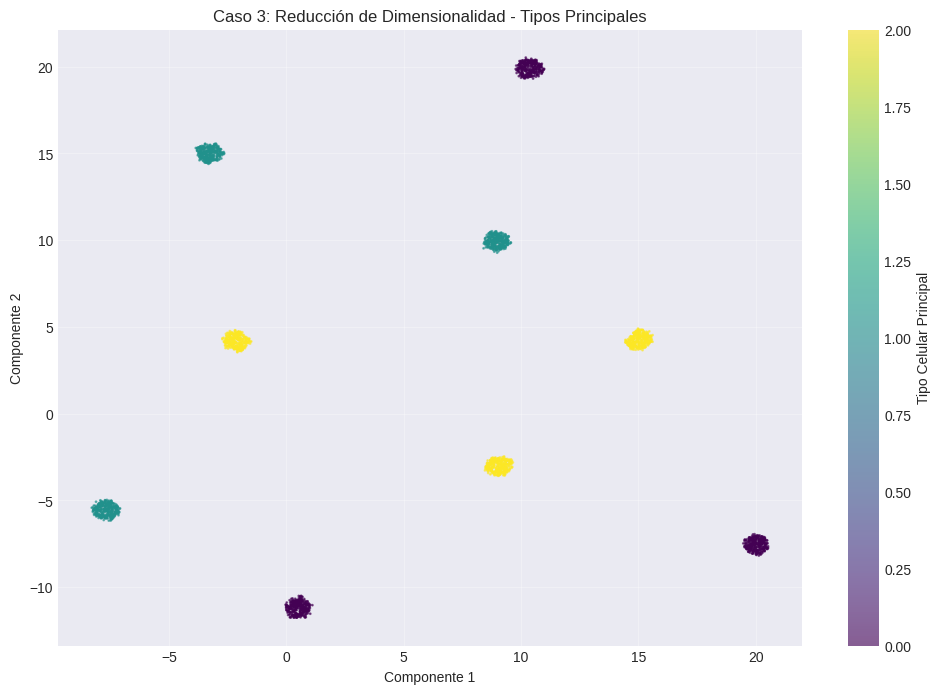

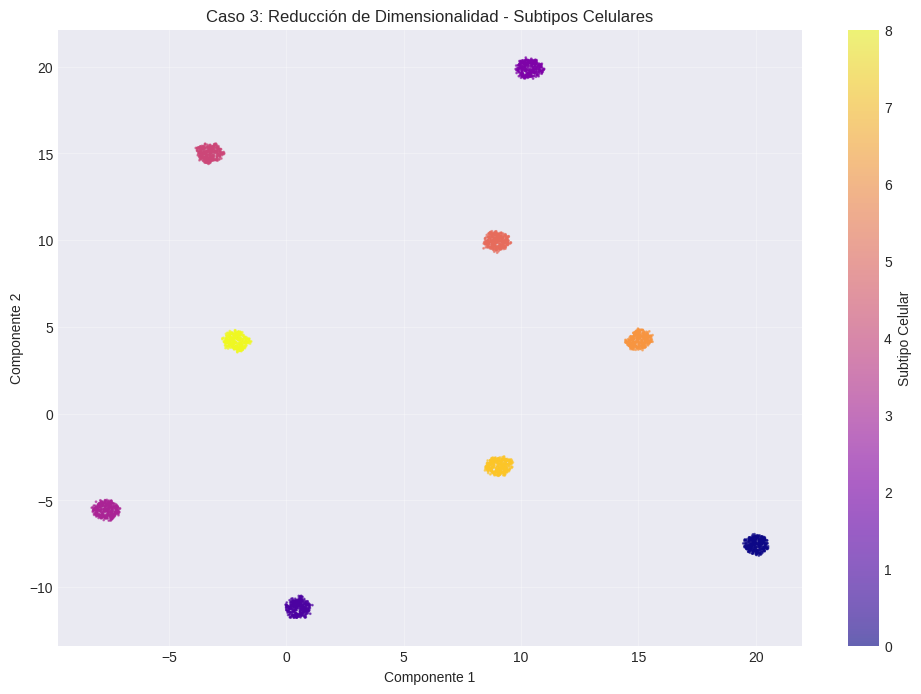

In [37]:
# TODO: Visualizar los resultados
# Crear dos gráficos: uno por tipos principales y otro por subtipos

# Grafico de Tipos Principales
plt.figure(figsize=(12, 8))
scatter_tipo = plt.scatter(X_reducido_caso3[:, 0], X_reducido_caso3[:, 1],
                           c=pd.Series(type_labels_caso3).astype('category').cat.codes, cmap='viridis', alpha=0.6, s=1)
plt.colorbar(scatter_tipo, label='Tipo Celular Principal')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.title('Caso 3: Reducción de Dimensionalidad - Tipos Principales')
plt.grid(True, alpha=0.3)
plt.show()

# Grafico de Subtipos Celulares
plt.figure(figsize=(12, 8))
scatter_subtipo = plt.scatter(X_reducido_caso3[:, 0], X_reducido_caso3[:, 1],
                              c=pd.Series(subtype_labels_caso3).astype('category').cat.codes, cmap='plasma', alpha=0.6, s=1)
plt.colorbar(scatter_subtipo, label='Subtipo Celular')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.title('Caso 3: Reducción de Dimensionalidad - Subtipos Celulares')
plt.grid(True, alpha=0.3)
plt.show()

### 3.6. Análisis de Resultados - Caso 3

**Preguntas:**

1. ¿Se pueden distinguir los 3 tipos celulares principales?
2. ¿Se pueden ver los subtipos dentro de cada tipo?
3. ¿Se preserva la estructura jerárquica?
4. ¿Los tipos celulares mantienen sus distancias relativas?
5. ¿Qué ventajas ofrece la técnica elegida para este tipo de datos?

**Respuestas:**

1. Sí se pueden distinguir


---

# Comparación de Resultados

## Resumen de Técnicas Utilizadas

Completa la siguiente tabla con las técnicas que elegiste para cada caso:

| Caso | Dataset | Técnica Elegida | Razón Principal |
|------|---------|-----------------|------------------|
| 1 | Indicadores Socioeconómicos | ___________ | ___________ |
| 2 | Fashion-MNIST | ___________ | ___________ |
| 3 | Expresión Genética | ___________ | ___________ |

## Reflexión sobre las Diferencias

**Responde:**

1. ¿Por qué una técnica funciona mejor que otra según el tipo de datos?

*[TU RESPUESTA]*

2. ¿Qué características del dataset te ayudaron a decidir qué técnica usar?

*[TU RESPUESTA]*

3. ¿En qué casos sería útil combinar técnicas (ej: PCA → t-SNE)?

*[TU RESPUESTA]*

---

# Conclusiones Finales

## Aprendizajes del Laboratorio

Escribe tus conclusiones sobre lo aprendido en este laboratorio:

### 1. Sobre PCA:

*[TUS CONCLUSIONES SOBRE PCA]*

### 2. Sobre t-SNE:

*[TUS CONCLUSIONES SOBRE t-SNE]*

### 3. Sobre UMAP:

*[TUS CONCLUSIONES SOBRE UMAP]*

### 4. Comparación General:

*[TUS CONCLUSIONES COMPARATIVAS]*

### 5. Aplicaciones Prácticas:

*[CÓMO APLICARÍAS LO APRENDIDO EN PROYECTOS REALES]*

---

## Referencias

- Scikit-learn Documentation: https://scikit-learn.org/
- UMAP Documentation: https://umap-learn.readthedocs.io/
- Fashion-MNIST: https://github.com/zalandoresearch/fashion-mnist

---
